In [ ]:
import pandas as pd
import numpy as np
from cdc_ml.config import POLLS_PROCESSED,CUSTOMER_CLASS_PROCESSED
import xgboost as xgb
from cdc_ml.features.build_features import assign_class_type
from sklearn.model_selection import StratifiedGroupKFold
import seaborn as sns

from sklearn.metrics import brier_score_loss, average_precision_score
from sklearn.inspection import permutation_importance

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import PercentFormatter
from cdc_ml.features.build_features import drop_meta_high_card_cols
from cdc_ml.plots import platt_recal
from sklearn.ensemble import RandomForestClassifier

In [24]:
df = pd.read_parquet(POLLS_PROCESSED)
df_class = pd.read_parquet(CUSTOMER_CLASS_PROCESSED)

In [25]:
df= assign_class_type(df,df_class)

In [26]:
df = df.loc[~(df["username"]=="anmol")]

In [27]:
df.sort_values(by='cycle_start').tail()

,id,username,cycle_start,cycle_end,polling_at,booking_hour,has_booking,cycle_start_month,cycle_start_day,cycle_start_dow,cycle_start_hour,polling_month,polling_day,polling_dow,polling_hour,hours_into_cycle,class_type,is_one_team
2047,2047,ali,2026-04-21 00:00:00+08:00,2026-04-25 23:59:00+08:00,2026-04-24 14:00:00+08:00,NaT,False,4,21,1,0,4,24,4,14,86.0,0,1
2048,2048,ali,2026-04-21 00:00:00+08:00,2026-04-25 23:59:00+08:00,2026-04-24 15:00:00+08:00,NaT,False,4,21,1,0,4,24,4,15,87.0,0,1
2049,2049,ali,2026-04-21 00:00:00+08:00,2026-04-25 23:59:00+08:00,2026-04-24 16:00:00+08:00,NaT,False,4,21,1,0,4,24,4,16,88.0,0,1
2021,2021,ali,2026-04-21 00:00:00+08:00,2026-04-25 23:59:00+08:00,2026-04-23 12:00:00+08:00,NaT,False,4,21,1,0,4,23,3,12,60.0,0,1
1961,1961,ali,2026-04-21 00:00:00+08:00,2026-04-25 23:59:00+08:00,2026-04-21 00:00:00+08:00,NaT,False,4,21,1,0,4,21,1,0,0.0,0,1


In [28]:
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
tr, te = next(sgkf.split(df, y=df["has_booking"], groups=df["username"]))
df_train, df_test = df.iloc[tr], df.iloc[te]

In [29]:
df_train

,id,username,cycle_start,cycle_end,polling_at,booking_hour,has_booking,cycle_start_month,cycle_start_day,cycle_start_dow,cycle_start_hour,polling_month,polling_day,polling_dow,polling_hour,hours_into_cycle,class_type,is_one_team
0,0,addity,2025-08-13 21:00:00+08:00,2025-08-28 11:36:00+08:00,2025-08-13 21:00:00+08:00,NaT,False,8,13,2,21,8,13,2,21,0.00,1,1
1,1,addity,2025-08-13 21:00:00+08:00,2025-08-28 11:36:00+08:00,2025-08-13 22:00:00+08:00,NaT,False,8,13,2,21,8,13,2,22,1.00,1,1
2,2,addity,2025-08-13 21:00:00+08:00,2025-08-28 11:36:00+08:00,2025-08-13 23:00:00+08:00,NaT,False,8,13,2,21,8,13,2,23,2.00,1,1
3,3,addity,2025-08-13 21:00:00+08:00,2025-08-28 11:36:00+08:00,2025-08-14 00:00:00+08:00,NaT,False,8,13,2,21,8,14,3,0,3.00,1,1
4,4,addity,2025-08-13 21:00:00+08:00,2025-08-28 11:36:00+08:00,2025-08-14 01:00:00+08:00,NaT,False,8,13,2,21,8,14,3,1,4.00,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31525,31525,srpr,2026-02-17 13:03:00+08:00,2026-03-02 12:00:00+08:00,2026-03-02 07:00:00+08:00,NaT,False,2,17,1,13,3,2,0,7,305.95,0,0
31526,31526,srpr,2026-02-17 13:03:00+08:00,2026-03-02 12:00:00+08:00,2026-03-02 08:00:00+08:00,NaT,False,2,17,1,13,3,2,0,8,306.95,0,0
31527,31527,srpr,2026-02-17 13:03:00+08:00,2026-03-02 12:00:00+08:00,2026-03-02 09:00:00+08:00,NaT,False,2,17,1,13,3,2,0,9,307.95,0,0
31528,31528,srpr,2026-02-17 13:03:00+08:00,2026-03-02 12:00:00+08:00,2026-03-02 10:00:00+08:00,NaT,False,2,17,1,13,3,2,0,10,308.95,0,0


In [30]:
print(len(df_train)/len(df))
print(len(df_test)/len(df))

0.8146159387073538
0.1853840612926462


In [31]:
df_train["username"].value_counts(normalize=True).sort_values()

username
ranjith    0.001447
ajithak    0.002050
max        0.002050
isyaf      0.002934
bhara      0.005788
pakning    0.006069
sara       0.007195
carol      0.007717
phuc       0.008400
nur        0.008722
aswath     0.009003
d          0.010611
lucinda    0.011817
bryan      0.014268
np         0.017082
addity     0.019293
bw         0.019333
fir        0.020941
natar      0.022186
gohguan    0.028376
apple      0.031632
jun        0.033762
joy        0.033842
brendon    0.041961
faith      0.045860
srpr       0.060571
ali        0.062299
matt       0.063264
mya        0.066559
anaya      0.069534
ryan       0.079059
flower     0.091158
jy         0.095217
Name: proportion, dtype: float64

In [32]:
df_test["username"].value_counts(normalize=True).sort_values()

username
poopie    0.134581
tomato    0.190569
kim       0.674850
Name: proportion, dtype: float64

In [33]:
df_train["has_booking"].mean()

np.float64(0.012942122186495177)

In [34]:
df_test["has_booking"].mean()

np.float64(0.014482515012363122)

In [35]:
def baseline_const(X_tr, y_tr):
    return X_tr.assign(_y=y_tr)["_y"].mean()


def joint_lut_hier(X_tr, y_tr, X_va, alpha_marg=10.0, alpha_cell=10.0):
    df = X_tr.assign(_y=y_tr)
    base = df["_y"].mean()
    z0 = np.log(base / (1 - base))

    # 1) smoothed marginal logit deviations (shrink toward base)
    def marg_dev(col, a):
        g = df.groupby(col)["_y"]
        rate = (g.sum() + a * base) / (g.count() + a)
        return np.log(rate / (1 - rate)) - z0  # cat -> logit deviation

    d_dow, d_hour = marg_dev("polling_dow", alpha_marg), marg_dev("polling_hour", alpha_marg)

    # additive prediction (probability) for any (dow, hour) rows
    def add_prior(frame):
        z = (
            z0
            + frame["polling_dow"].map(d_dow).fillna(0.0)
            + frame["polling_hour"].map(d_hour).fillna(0.0)
        )
        return 1 / (1 + np.exp(-z))

    # 2) joint cell rate, shrunk toward the ADDITIVE prior (not toward base)
    cell = df.groupby(["polling_dow", "polling_hour"])["_y"].agg(n="size", m="mean")
    prior = add_prior(cell.reset_index()).to_numpy()
    cell["_rate"] = (cell["n"] * cell["m"] + alpha_cell * prior) / (cell["n"] + alpha_cell)

    # 3) map val rows; unseen cell -> additive prior (which backs off to base)
    merged = X_va[["polling_dow", "polling_hour"]].merge(
        cell["_rate"].reset_index(), on=["polling_dow", "polling_hour"], how="left"
    )
    p = np.where(merged["_rate"].isna(), add_prior(X_va).to_numpy(), merged["_rate"].to_numpy())
    return np.clip(p, 1e-6, 1 - 1e-6)


def additive_lut_logit(X_tr, y_tr, X_va, alpha=10.0):
    df = X_tr.assign(_y=y_tr)
    base = df["_y"].mean()
    z0 = np.log(base / (1 - base))  # logit(base)

    def smoothed_logit(col):
        g = df.groupby(col)["_y"]
        rate = (g.sum() + alpha * base) / (g.count() + alpha)  # shrink toward base
        return np.log(rate / (1 - rate))  # finite by construction

    zd = smoothed_logit("polling_dow")  # Series: dow -> logit
    zh = smoothed_logit("polling_hour")  # Series: hour -> logit

    d_dow = (X_va["polling_dow"].map(zd) - z0).fillna(0.0)  # unseen -> 0 deviation
    d_hour = (X_va["polling_hour"].map(zh) - z0).fillna(0.0)

    z = z0 + d_dow + d_hour
    p = 1 / (1 + np.exp(-z))
    return p.clip(1e-6, 1 - 1e-6).to_numpy()


def marg_dow_baseline(X_tr, y_tr, X_va, alpha=10.0):
    """
    Marginal baseline by polling_dow with Laplace smoothing.

    Args:
        X_tr, y_tr: training features and labels
        X_va: validation features
        alpha: smoothing strength (higher = more shrinkage toward base)
               Laplace = 1, but 5-20 often works better empirically

    Returns:
        np.array of predictions
    """
    base = y_tr.mean()

    # Compute counts and successes per dow
    counts = (
        X_tr.assign(_y=y_tr)
        .groupby("polling_dow")
        .agg(successes=("_y", "sum"), total=("_y", "count"))
        .reset_index()
    )

    # Shrink toward base: (successes + alpha*base) / (total + alpha)
    counts["_y"] = (counts["successes"] + alpha * base) / (counts["total"] + alpha)

    p_marg = (
        X_va[["polling_dow"]]
        .merge(counts[["polling_dow", "_y"]], on="polling_dow", how="left")["_y"]
        .fillna(base)
        .to_numpy()
    )
    return p_marg


def marg_hour_baseline(X_tr, y_tr, X_va, alpha=10.0):
    """
    Marginal baseline by polling_hour with Laplace smoothing.

    Args:
        X_tr, y_tr: training features and labels
        X_va: validation features
        alpha: smoothing strength (higher = more shrinkage toward base)

    Returns:
        np.array of predictions
    """
    base = y_tr.mean()

    # Compute counts and successes per hour
    counts = (
        X_tr.assign(_y=y_tr)
        .groupby("polling_hour")
        .agg(successes=("_y", "sum"), total=("_y", "count"))
        .reset_index()
    )

    # Shrink toward base
    counts["_y"] = (counts["successes"] + alpha * base) / (counts["total"] + alpha)

    p_marg = (
        X_va[["polling_hour"]]
        .merge(counts[["polling_hour", "_y"]], on="polling_hour", how="left")["_y"]
        .fillna(base)
        .to_numpy()
    )
    return p_marg


def train(
    df: pd.DataFrame,
    seed=42,
):

    y = df["has_booking"].to_numpy()
    X = drop_meta_high_card_cols(df)[["polling_dow", "polling_hour"]]
    print(X.sample())
    n = len(y)
    oof_xgb = np.full(n, np.nan)
    oof_marg_dow = np.full(n, np.nan)
    oof_marg_hour = np.full(n, np.nan)
    oof_joint = np.full(n, np.nan)
    oof_const = np.full(n, np.nan)
    oof_add = np.full(n, np.nan)
    oof_rf = np.full(n, np.nan)

    tr_brier_list, tr_pr_list = [], []
    rf_brier_list, rf_pr_list = [], []
    val_brier_list, val_pr_list = [], []
    marg_dow_brier_list, marg_dow_pr_list = [], []
    marg_hour_brier_list, marg_hour_pr_list = [], []
    joint_brier_list, joint_pr_list = [], []
    const_brier_list, const_pr_list = [], []
    add_brier_list, add_pr_list = [], []
    models = []
    whales_pt_mask = df["username"].isin(["anmol", "jy", "mya"]).to_numpy()
    whales_pc_mask = df["username"].isin(["kim", "jy", "flower"]).to_numpy()
    sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=120)
    importances = []
    importances_std = []
    for fold, (tr, va) in enumerate(sgkf.split(X, y=df["has_booking"], groups=df["username"])):
        X_tr, y_tr = X.iloc[tr], y[tr]
        X_va, y_va = X.iloc[va], y[va]
        # print("----------------------------")
        # print(df.iloc[va].groupby(["username"])["has_booking"].mean().sort_values())
        # --- XGBoost ---
        model = xgb.XGBClassifier(
            n_estimators=500,
            objective="binary:logistic",
            learning_rate=0.03,
            max_depth=2,
            min_child_weight=10,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=10.0,
            tree_method="hist",
            random_state=seed,
            n_jobs=-1,
        )
        model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
        models.append(model)

        # --- RandomForest ---
        rf = RandomForestClassifier(
            n_estimators=500,
            max_depth=6,
            min_samples_leaf=50,
            max_features=None,   # only 2 features — let every split see both; diversity comes from bagging
            n_jobs=-1,
            random_state=seed,
        )
        rf.fit(X_tr, y_tr)
        oof_rf[va] = rf.predict_proba(X_va)[:, 1]

        r = permutation_importance(
            model,
            X_va,
            y_va,
            n_repeats=10,
            random_state=seed,
            n_jobs=-1,
            scoring="average_precision",
        )

        importances.append(r.importances_mean)
        importances_std.append(r.importances_std)

        print(X.columns.tolist())
        print(r.importances_mean)

        oof_xgb[va] = model.predict_proba(X_va)[:, 1]
        tr_pred = model.predict_proba(X_tr)[:, 1]
        # --- marg baseline (dow × hour lookup) ---
        p_lut = joint_lut_hier(X_tr, y_tr, X_va)
        oof_joint[va] = p_lut
        marg_dow = marg_dow_baseline(X_tr, y_tr, X_va)
        marg_hour = marg_hour_baseline(X_tr, y_tr, X_va)
        add = additive_lut_logit(X_tr, y_tr, X_va)
        const = baseline_const(X_tr, y_tr)
        oof_const[va] = const
        oof_marg_dow[va] = marg_dow
        oof_marg_hour[va] = marg_hour
        oof_add[va] = add
        # --- per-fold scores ---
        fold_rf_brier = brier_score_loss(y_va, oof_rf[va])
        fold_rf_pr = average_precision_score(y_va, oof_rf[va])
        rf_brier_list.append(fold_rf_brier)
        rf_pr_list.append(fold_rf_pr)
        fold_tr_brier = brier_score_loss(y_tr, tr_pred)
        fold_tr_pr = average_precision_score(y_tr, tr_pred)
        fold_val_brier = brier_score_loss(y_va, oof_xgb[va])
        fold_val_pr = average_precision_score(y_va, oof_xgb[va])
        fold_joint_brier = brier_score_loss(y_va, p_lut)
        fold_joint_pr = average_precision_score(y_va, p_lut)
        fold_const_brier = brier_score_loss(y_va, oof_const[va])
        fold_const_pr = average_precision_score(y_va, oof_const[va])
        fold_marg_dow_brier = brier_score_loss(y_va, oof_marg_dow[va])
        fold_marg_dow_pr = average_precision_score(y_va, oof_marg_dow[va])
        fold_marg_hour_brier = brier_score_loss(y_va, oof_marg_hour[va])
        fold_marg_hour_pr = average_precision_score(y_va, oof_marg_hour[va])
        fold_add_brier = brier_score_loss(y_va, oof_add[va])
        fold_add_pr = average_precision_score(y_va, oof_add[va])
        tr_brier_list.append(fold_tr_brier)
        tr_pr_list.append(fold_tr_pr)
        val_brier_list.append(fold_val_brier)
        val_pr_list.append(fold_val_pr)
        joint_brier_list.append(fold_joint_brier)
        joint_pr_list.append(fold_joint_pr)
        marg_dow_brier_list.append(fold_marg_dow_brier)
        marg_dow_pr_list.append(fold_marg_dow_pr)
        marg_hour_brier_list.append(fold_marg_hour_brier)
        marg_hour_pr_list.append(fold_marg_hour_pr)
        const_brier_list.append(fold_const_brier)
        const_pr_list.append(fold_const_pr)
        add_brier_list.append(fold_add_brier)
        add_pr_list.append(fold_add_pr)
        # --- fold report ---
        tr_dates = df.iloc[tr]["cycle_start"]
        va_dates = df.iloc[va]["cycle_start"]
        print(
            f"fold {fold}: "
            f"train n={len(tr):>6} ({tr_dates.min().date()} → {tr_dates.max().date()})  "
            f"val n={len(va):>6} ({va_dates.min().date()} → {va_dates.max().date()})  \n"
            f"  train_pos={y_tr.mean():.3f}  val_pos={y_va.mean():.3f}  \n"
            f"  marg_dow_brier={fold_marg_dow_brier:.4f}  marg_dow_pr={fold_marg_dow_pr:.4f}  \n"
            f"  marg_hour_brier={fold_marg_hour_brier:.4f}  marg_hour_pr={fold_marg_hour_pr:.4f}  \n"
            f"  add_brier={fold_add_brier:.4f}  add_pr={fold_add_pr:.4f}  \n"
            f"  joint_brier={fold_joint_brier:.4f}  joint_pr={fold_joint_pr:.4f}  \n"
            f"  rf_brier_val={fold_rf_brier:.4f}  rf_pr_val={fold_rf_pr:.4f}  \n"
            f"  xgb_brier_val={fold_val_brier:.4f}  xgb_pr_val={fold_val_pr:.4f}  \n"
            f"  xgb_brier_tr={fold_tr_brier:.4f}  xgb_pr_tr={fold_tr_pr:.4f}  \n"
        )

    def _row(name, brier_list, pr_list, oof_arr):
        b_pool = brier_score_loss(y, oof_arr)
        p_pool = average_precision_score(y, oof_arr)
        return (
            f"{name:<7} brier={b_pool:.4f} ({np.mean(brier_list):.4f}±{np.std(brier_list):.4f}) lift={b_pool/y.mean()}   "
            f"pr_auc={p_pool:.4f} ({np.mean(pr_list):.4f}±{np.std(pr_list):.4f}) lift={p_pool/y.mean()}"
        )

    whale_pt_base = y[whales_pt_mask].mean()
    non_whale_pt_base = y[~whales_pt_mask].mean()
    whale_pc_base = y[whales_pc_mask].mean()
    non_whale_pc_base = y[~whales_pc_mask].mean()

    whales_brier_joint = brier_score_loss(y[whales_pc_mask], oof_joint[whales_pc_mask])
    whales_pr_joint = average_precision_score(y[whales_pt_mask], oof_joint[whales_pt_mask])
    non_whales_brier_joint = brier_score_loss(y[~whales_pc_mask], oof_joint[~whales_pc_mask])
    non_whales_pr_joint = average_precision_score(y[~whales_pt_mask], oof_joint[~whales_pt_mask])

    whales_brier_xgb = brier_score_loss(y[whales_pc_mask], oof_xgb[whales_pc_mask])
    whales_pr_xgb = average_precision_score(y[whales_pt_mask], oof_xgb[whales_pt_mask])
    non_whales_brier_xgb = brier_score_loss(y[~whales_pc_mask], oof_xgb[~whales_pc_mask])
    non_whales_pr_xgb = average_precision_score(y[~whales_pt_mask], oof_xgb[~whales_pt_mask])

    whales_brier_rf = brier_score_loss(y[whales_pc_mask], oof_rf[whales_pc_mask])
    whales_pr_rf = average_precision_score(y[whales_pt_mask], oof_rf[whales_pt_mask])
    non_whales_brier_rf = brier_score_loss(y[~whales_pc_mask], oof_rf[~whales_pc_mask])
    non_whales_pr_rf = average_precision_score(y[~whales_pt_mask], oof_rf[~whales_pt_mask])

    mean_importance = np.mean(importances, axis=0)
    mean_std = np.mean(importances_std, axis=0)

    avg_df = pd.DataFrame(
        {"feature": X.columns, "mean": mean_importance, "std": mean_std}
    ).sort_values("mean", ascending=False)

    print(
        f"\nOOF  base_rate={y.mean():.4f}  n={len(y)}/{n}      "
        f"format: pooled (mean±std over folds)\n"
        f"{_row('const', const_brier_list, const_pr_list, oof_const)}\n"
        f"{_row('marg_dow',  marg_dow_brier_list,  marg_dow_pr_list,  oof_marg_dow)}\n"
        f"{_row('marg_hour',  marg_hour_brier_list,  marg_hour_pr_list,  oof_marg_hour)}\n"
        f"{_row("add",  add_brier_list,  add_pr_list,  oof_add)}\n"
        f"{_row('joint',  joint_brier_list,  joint_pr_list,  oof_joint)}\n"
        f"          whales brier={whales_brier_joint} lift={ whales_brier_joint/whale_pc_base}\n"
        f"          non whales brier={non_whales_brier_joint} lift={non_whales_brier_joint/non_whale_pc_base}\n"
        f"          whales pr={whales_pr_joint} lift={whales_pr_joint/whale_pt_base}\n"
        f"          non whales pr={non_whales_pr_joint} lift={non_whales_pr_joint/non_whale_pt_base}\n"
        f"{_row('rf', rf_brier_list, rf_pr_list, oof_rf)}\n"
f"          whales brier={whales_brier_rf} lift={whales_brier_rf/whale_pc_base}\n"
f"          non whales brier={non_whales_brier_rf} lift={non_whales_brier_rf/non_whale_pc_base}\n"
f"          whales pr={whales_pr_rf} lift={whales_pr_rf/whale_pt_base}\n"
f"          non whales pr={non_whales_pr_rf} lift={non_whales_pr_rf/non_whale_pt_base}\n"
        f"{_row('xgb',   val_brier_list,   val_pr_list,   oof_xgb)}\n"
        f"          whales brier={whales_brier_xgb} lift={whales_brier_xgb/whale_pc_base}\n"
        f"          non whales brier={non_whales_brier_xgb} lift={non_whales_brier_xgb/non_whale_pc_base}\n"
        f"          whales pr={whales_pr_xgb} lift={whales_pr_xgb/whale_pt_base}\n"
        f"          non whales pr={non_whales_pr_xgb} lift={non_whales_pr_xgb/non_whale_pt_base}\n"
        f"xgb_tr  brier=  ---   ({np.mean(tr_brier_list):.4f}±{np.std(tr_brier_list):.4f})   "
        f"pr_auc=  ---   ({np.mean(tr_pr_list):.4f}±{np.std(tr_pr_list):.4f})\n"
        f"Average importances \n{avg_df}"
    )
    return oof_xgb, oof_joint, oof_const, oof_add, models, whales_pc_mask


In [36]:
#seed = np.random.randint(0,100)
seed = 42
# if the features below is not removed , the model will overfit 
oof_xgb,oof_joint,oof_const,oof_add,models,whale_mask=train(df_train,seed)

       polling_dow  polling_hour
28289            6            12
['polling_dow', 'polling_hour']
[0.00378258 0.01168331]
fold 0: train n= 20137 (2025-08-12 → 2026-04-21)  val n=  4743 (2025-09-02 → 2026-03-21)  
  train_pos=0.013  val_pos=0.013  
  marg_dow_brier=0.0133  marg_dow_pr=0.0173  
  marg_hour_brier=0.0132  marg_hour_pr=0.0275  
  add_brier=0.0132  add_pr=0.0314  
  joint_brier=0.0134  joint_pr=0.0280  
  rf_brier_val=0.0132  rf_pr_val=0.0316  
  xgb_brier_val=0.0132  xgb_pr_val=0.0307  
  xgb_brier_tr=0.0125  xgb_pr_tr=0.0397  

['polling_dow', 'polling_hour']
[0.00423691 0.02109517]
fold 1: train n= 19612 (2025-08-12 → 2026-04-21)  val n=  5268 (2025-08-16 → 2026-04-01)  
  train_pos=0.013  val_pos=0.013  
  marg_dow_brier=0.0124  marg_dow_pr=0.0127  
  marg_hour_brier=0.0122  marg_hour_pr=0.0329  
  add_brier=0.0122  add_pr=0.0343  
  joint_brier=0.0123  joint_pr=0.0362  
  rf_brier_val=0.0122  rf_pr_val=0.0375  
  xgb_brier_val=0.0122  xgb_pr_val=0.0350  
  xgb_brier_tr=

In [37]:
"""Calibration reliability diagrams segmented by polling-volume whales.

Drop into your viz/plotting module. Main entry point is
`plot_calibration_by_volume`, which takes pooled OOF predictions and plots
whale vs non-whale reliability curves with Wilson CIs plus prediction
histograms underneath.

Design choices baked in:
  * Segment on EXPOSURE (n_polls / is_whale), never on positive count — the
    slice must not be conditioned on the label.
  * Quantile (equal-count) bins, not equal-width, so no bin is mostly empty
    at the ~1.3% base rate. Edges are deduped, which also handles the
    discrete-prediction case (additive LUT emits one value per dow/hour cell).
  * Wilson score intervals for observed frequency — robust at low counts /
    extreme p, unlike the normal approximation.
  * Prediction histogram (log y) under the reliability axes so sparsity in the
    low-volume segment is visible rather than hidden.

Read points BELOW the diagonal as overprediction (observed < predicted) — the
non-whale failure mode you diagnosed.
"""

def wilson_interval(k, n, z=1.96):
    """95% Wilson score interval for a binomial proportion.

    Returns (p_hat, lower, upper). p_hat is the raw observed frequency (the
    plotted point); the interval is the Wilson score interval, which stays
    sensible when k is tiny or n is small.
    """
    k = np.asarray(k, dtype=float)
    n = np.asarray(n, dtype=float)
    p = np.divide(k, n, out=np.zeros_like(k, dtype=float), where=n > 0)
    denom = 1.0 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    half = (z / denom) * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2))
    lower = np.clip(center - half, 0.0, 1.0)
    upper = np.clip(center + half, 0.0, 1.0)
    return p, lower, upper


def _quantile_bin_index(p_pred, n_bins):
    """Assign each prediction to a quantile bin. Dedups edges, so the effective
    number of bins may be < n_bins when predictions are discrete (LUT) or
    heavily point-massed. Returns (edges, idx, n_effective)."""
    edges = np.quantile(p_pred, np.linspace(0.0, 1.0, n_bins + 1))
    edges = np.unique(edges)
    if len(edges) < 2:  # all predictions identical
        return edges, np.zeros(len(p_pred), dtype=int), 1
    idx = np.clip(np.digitize(p_pred, edges[1:-1], right=False), 0, len(edges) - 2)
    return edges, idx, len(edges) - 1


def reliability_table(p_pred, y_true, n_bins=10):
    """Per-bin mean predicted prob, observed freq, Wilson CI, and count."""
    p_pred = np.asarray(p_pred, dtype=float)
    y_true = np.asarray(y_true, dtype=float)
    _, idx, n_eff = _quantile_bin_index(p_pred, n_bins)

    x, k_arr, n_arr = [], [], []
    for b in range(n_eff):
        mask = idx == b
        n = int(mask.sum())
        if n == 0:
            continue
        x.append(p_pred[mask].mean())
        k_arr.append(y_true[mask].sum())
        n_arr.append(n)

    x = np.array(x)
    k_arr = np.array(k_arr)
    n_arr = np.array(n_arr)
    obs, lo, hi = wilson_interval(k_arr, n_arr)
    return {"x": x, "obs": obs, "lo": lo, "hi": hi, "n": n_arr, "k": k_arr}


def plot_calibration_by_volume(
    p_pred,
    y_true,
    is_whale,
    *,
    n_bins=10,
    title="Calibration by polling volume (pooled OOF)",
    ax_range=None,
):
    """Reliability diagram for whale vs non-whale segments.

    Parameters
    ----------
    p_pred : array of predicted P(has_booking) per polling row (pooled OOF).
    y_true : array of 0/1 has_booking labels, same length.
    is_whale : bool array, True for high-n_polls users. Use the SAME whale
        definition as your baseline sweep so the graph matches your weighting.
    n_bins : requested quantile bins (effective count may be lower).
    """
    p_pred = np.asarray(p_pred, dtype=float)
    y_true = np.asarray(y_true, dtype=float)
    is_whale = np.asarray(is_whale, dtype=bool)

    segments = {
        "whale (high n_polls)": (is_whale, "#2563eb"),
        "non-whale": (~is_whale, "#dc2626"),
    }

    if ax_range is None:
        hi_x = float(np.quantile(p_pred, 0.999))
        ax_range = (0.0, max(hi_x, float(y_true.mean()) * 3.0))

    fig = plt.figure(figsize=(20,10))
    gs = GridSpec(2, 1, height_ratios=[3, 1], hspace=0.07)
    ax = fig.add_subplot(gs[0])
    axh = fig.add_subplot(gs[1], sharex=ax)

    # perfect-calibration reference
    ax.plot(ax_range, ax_range, ls="--", lw=1.0, color="#6b7280", label="perfect", zorder=1)

    for name, (mask, color) in segments.items():
        if mask.sum() == 0:
            continue
        t = reliability_table(p_pred[mask], y_true[mask], n_bins=n_bins)
        yerr = np.vstack(
            [np.clip(t["obs"] - t["lo"], 0, None), np.clip(t["hi"] - t["obs"], 0, None)]
        )
        ax.errorbar(
            t["x"],
            t["obs"],
            yerr=yerr,
            marker="o",
            ms=4.5,
            lw=1.6,
            capsize=2.5,
            color=color,
            zorder=3,
            label=f"{name}  (base={y_true[mask].mean():.2%}, " f"N={mask.sum():,})",
        )
        axh.hist(p_pred[mask], bins=40, range=ax_range, alpha=0.5, color=color, label=name)

    ax.set_xlim(*ax_range)
    ax.set_ylim(0, ax_range[1])
    ax.set_ylabel("Observed frequency")
    ax.set_title(title)
    ax.legend(loc="upper left", fontsize=9, frameon=False)
    ax.xaxis.set_major_formatter(PercentFormatter(xmax=1.0))
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
    ax.text(
        0.97,
        0.04,
        "below diagonal = overprediction",
        transform=ax.transAxes,
        ha="right",
        fontsize=8.5,
        color="#6b7280",
        style="italic",
    )
    plt.setp(ax.get_xticklabels(), visible=False)

    axh.set_yscale("log")
    axh.set_ylabel("rows")
    axh.set_xlabel("Predicted P(has_booking)")
    axh.xaxis.set_major_formatter(PercentFormatter(xmax=1.0))
    axh.legend(loc="upper right", fontsize=8, frameon=False)

    fig.align_ylabels([ax, axh])


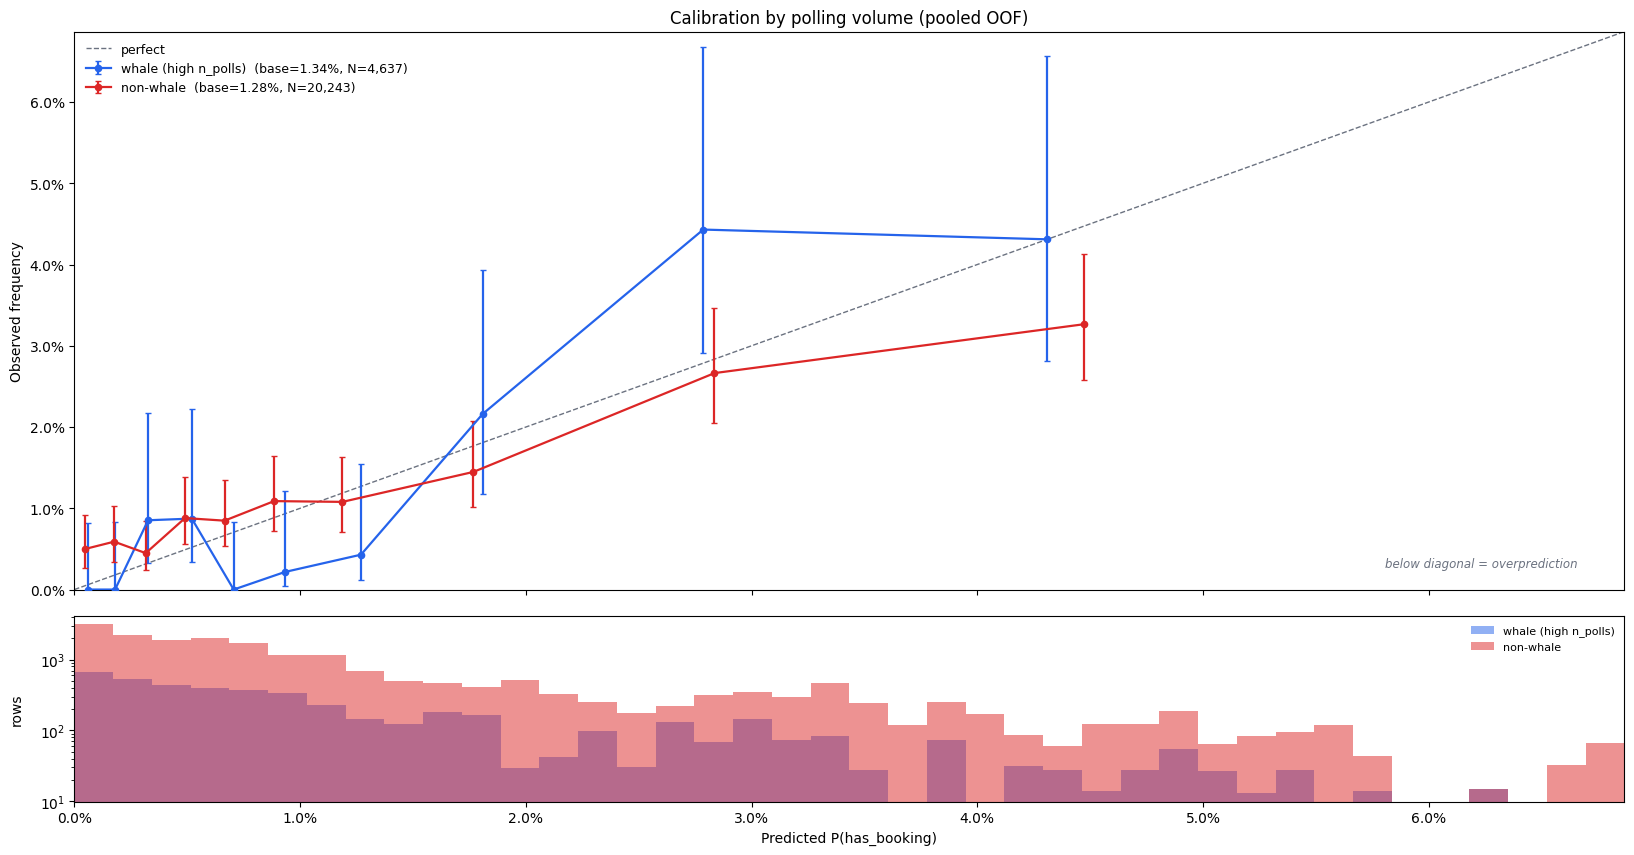

In [38]:
plot_calibration_by_volume(oof_add,df_train["has_booking"],whale_mask)

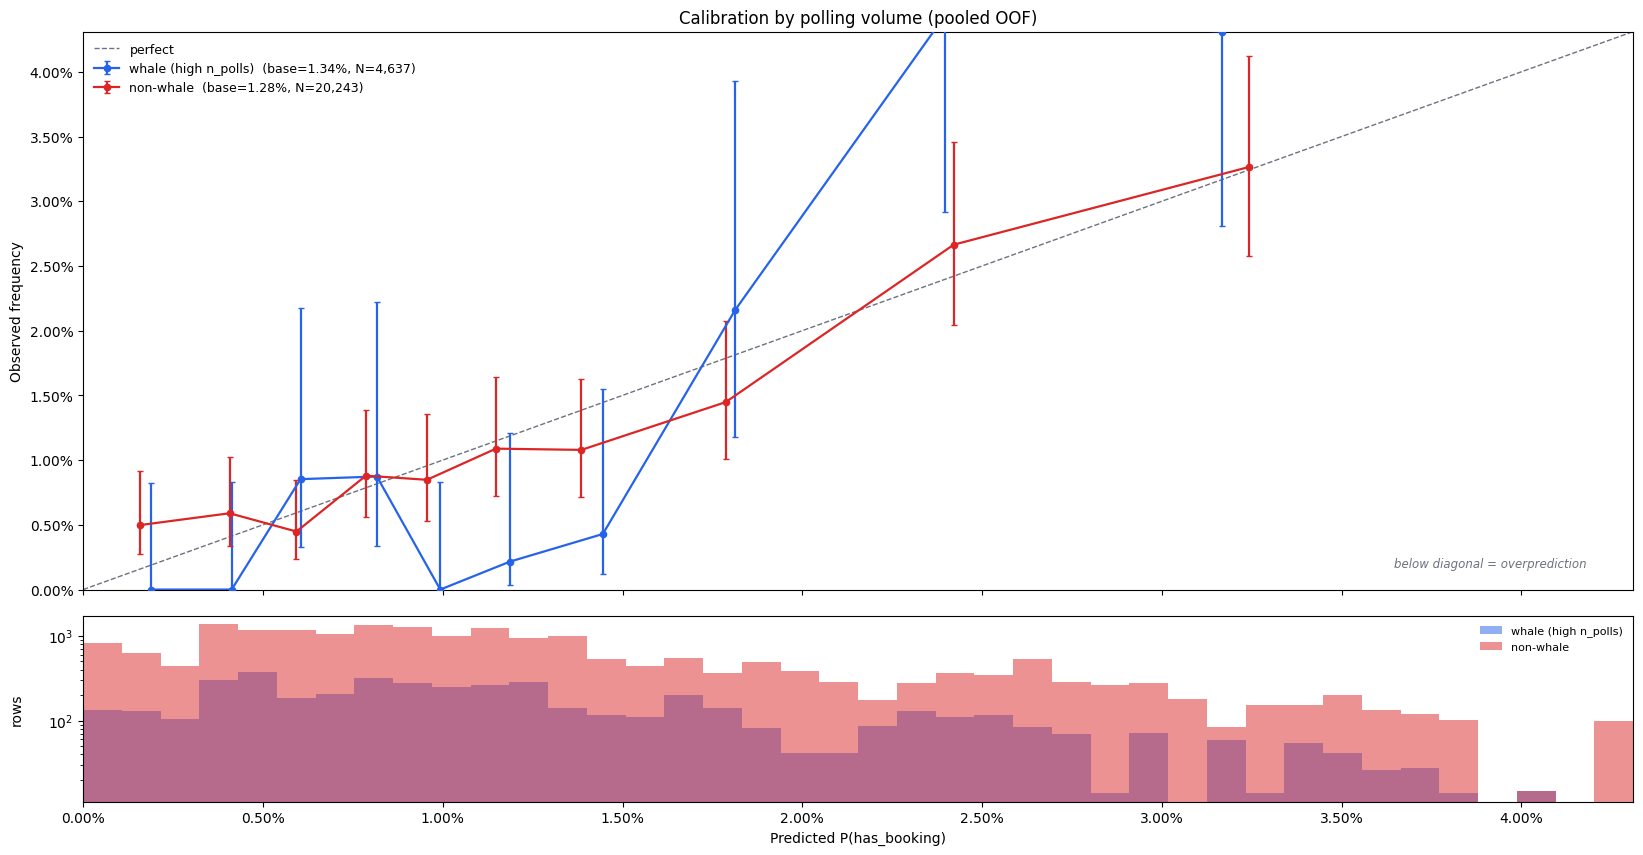

In [39]:
p_cal = platt_recal(oof_add,df_train)
plot_calibration_by_volume(p_cal,df_train["has_booking"],whale_mask)

In [40]:
print(oof_add)

[0.00534417 0.00793023 0.00404592 ... 0.02857667 0.01756781 0.03220269]


poll 91/168 cells (55% of polling) -> 91% of bookings


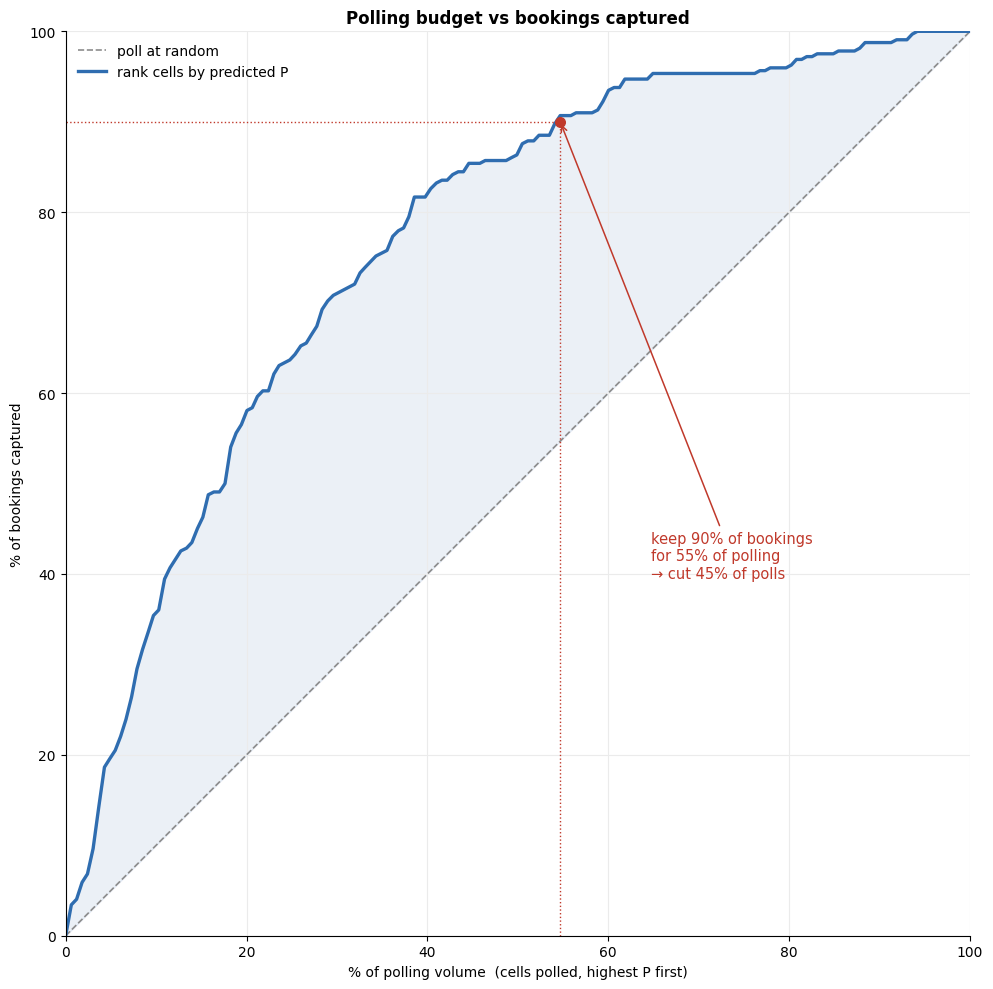

top 10% polling -> 36.0% bookings (lift 3.50x)
top 20% polling -> 58.1% bookings (lift 2.90x)
top 30% polling -> 71.1% bookings (lift 2.36x)
top 50% polling -> 87.6% bookings (lift 1.73x)
top 60% polling -> 93.5% bookings (lift 1.56x)


In [41]:
cell = (
    df_train.assign(oof=oof_add)                    # oof_xgb is already row-aligned to df_train
            .groupby(["polling_dow", "polling_hour"])
            .agg(pred=("oof", "mean"),              # cell's predicted P (mean over folds)
                 polls=("has_booking", "size"),     # volume = rows in the cell
                 bookings=("has_booking", "sum"))   # actual bookings in the cell
            .reset_index()
            .sort_values("pred", ascending=False)   # rank cells by P — and DON'T re-sort after
            .reset_index(drop=True)
)
cell["cum_polls"]    = cell["polls"].cumsum()                       # ONE global cumsum down the ranking
cell["cum_bookings"] = cell["bookings"].cumsum()
cell["pct_polls"]    = cell["cum_polls"]    / cell["polls"].sum()    # x-axis: % of polling
cell["pct_bookings"] = cell["cum_bookings"] / cell["bookings"].sum() # y-axis: % of bookings caught
cell["lift"]         = cell["pct_bookings"] / cell["pct_polls"]

target_recall = 0.90                                                # keep 90% of bookings
tau = cell.loc[cell.pct_bookings >= target_recall, "pred"].iloc[0]  # implied threshold
cell["poll"] = cell["pred"] >= tau                                  # True = poll, else skip
schedule = cell.loc[cell.poll, ["polling_dow", "polling_hour", "pred"]]

print(f"poll {cell.poll.sum()}/{len(cell)} cells "
      f"({cell.loc[cell.poll,'polls'].sum()/cell.polls.sum():.0%} of polling) "
      f"-> {cell.loc[cell.poll,'bookings'].sum()/cell.bookings.sum():.0%} of bookings")

x = np.insert(cell["pct_polls"].to_numpy()*100, 0, 0)   # prepend origin
y = np.insert(cell["pct_bookings"].to_numpy()*100, 0, 0)

fig, ax = plt.subplots(figsize=(20,10))
ax.plot([0,100],[0,100], "--", color="0.55", lw=1.2, label="poll at random")
ax.fill_between(x, x, y, color="#3b6fb0", alpha=0.10)
ax.plot(x, y, color="#2f6db0", lw=2.4, label="rank cells by predicted P")

op = cell[cell["pct_bookings"] >= 0.90].iloc[0]          # smallest budget keeping 90% of bookings
ox = op["pct_polls"]*100
ax.scatter([ox],[90], s=48, color="#c0392b", zorder=6)
ax.vlines(ox, 0, 90, color="#c0392b", ls=":", lw=1)
ax.hlines(90, 0, ox, color="#c0392b", ls=":", lw=1)
ax.annotate(f"keep 90% of bookings\nfor {ox:.0f}% of polling\n→ cut {100-ox:.0f}% of polls",
            xy=(ox,90), xytext=(ox+10, 42), fontsize=10.5, color="#c0392b", va="center",
            arrowprops=dict(arrowstyle="->", color="#c0392b", lw=1.1))

ax.set_xlim(0,100); ax.set_ylim(0,100); ax.set_aspect("equal")
ax.set_xlabel("% of polling volume  (cells polled, highest P first)")
ax.set_ylabel("% of bookings captured")
ax.set_title("Polling budget vs bookings captured", fontweight="bold")
ax.legend(loc="upper left", frameon=False)
ax.grid(True, color="0.92", lw=0.8)
for s in ["top","right"]: ax.spines[s].set_visible(False)
fig.tight_layout(); plt.show()

for k in (10, 20, 30, 50, 60):                               # numbers for your slide text
    r = cell[cell.pct_polls >= k/100].iloc[0]
    print(f"top {k:>2d}% polling -> {r.pct_bookings:5.1%} bookings (lift {r.lift:.2f}x)")

<Axes: xlabel='polling_dow', ylabel='polling_hour'>

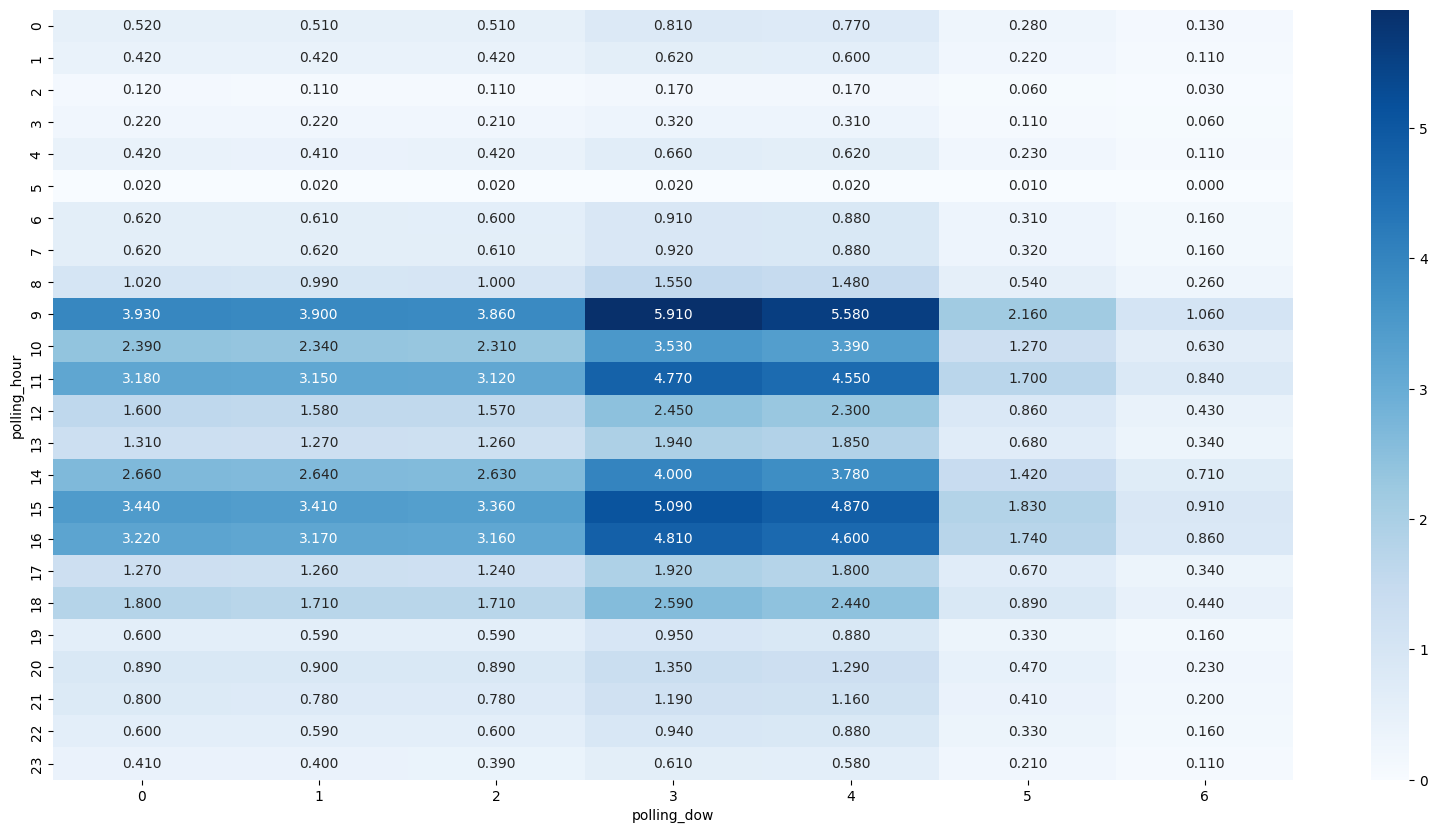

In [42]:
x = cell.pivot(index="polling_hour", columns="polling_dow", values="pred").mul(100).round(2)
fig,ax = plt.subplots(figsize=(20,10))
sns.heatmap(data=x,annot=True,fmt=".3f",cmap="Blues")

In [43]:
# from pathlib import Path
# from sklearn.model_selection import permutation_test_score
# from cdc_ml.features.build_features import drop_meta_high_card_cols
# from cdc_ml.modeling.train import time_ordered_kfold
# from cdc_ml.config import STAGE_1_PROCESSED

# def perm(
#     data_path: Path = STAGE_1_PROCESSED,
#     n_permutations: int = 1000,
#     seed: int = 42,
# ):
#     df = pd.read_parquet(data_path)
#     df_train, _ = temporal_split(df)

#     y = df_train["has_booking"].to_numpy()
#     X = drop_meta_high_card_cols(df_train).drop(columns=["has_booking"]+["cycle_start_month","cycle_start_day","cycle_start_dow","cycle_start_hour","polling_month","polling_day","hours_into_cycle","class_type","is_one_team"])

#     splits = list(time_ordered_kfold(df_train, time_col="cycle_start"))

#     clf = xgb.XGBClassifier(
#         n_estimators=500,
#         objective="binary:logistic",
#         eval_metric="aucpr",
#         learning_rate=0.03,
#         max_depth=1,
#         min_child_weight=10,
#         subsample=0.8,
#         colsample_bytree=0.8,
#         reg_lambda=1.0,
#         tree_method="hist",
#         device="cuda",
#         random_state=seed,
#         n_jobs=1,                  # let permutation_test_score parallelize
#     )

#     score, perm_scores, pvalue = permutation_test_score(
#         clf, X, y,
#         scoring="average_precision",
#         cv=splits,                 # pre-computed list of (train, val) index pairs
#         n_permutations=n_permutations,
#         n_jobs=-1,
#         random_state=seed,
#         verbose=1,
#     )

#     print(
#         f"\ntrue PR-AUC = {score:.4f}\n"
#         f"null        = {perm_scores.mean():.4f} ± {perm_scores.std():.4f}\n"
#         f"p-value     = {pvalue:.4f}  (n_perm={n_permutations})"
#     )

# perm(STAGE_1_PROCESSED)